In [3]:
import math

import numpy as np
import gdsfactory as gf
from gdsfactory.components import gaps

gf.gpdk.PDK.activate()

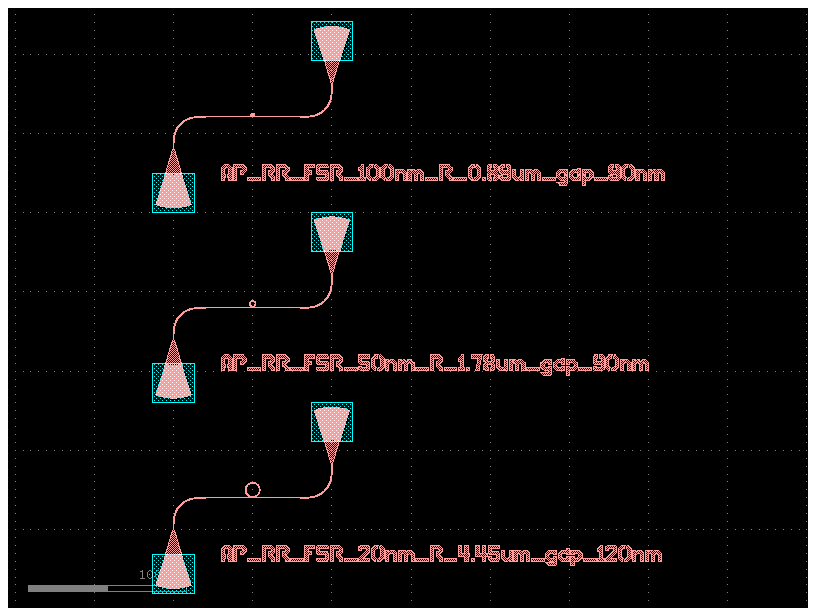

In [4]:
def All_pass_ring(wavelength = 1.55,
                  core_material= 0,
                  cladd_material= 0,
                  neff= 0,
                  ng = 4.296053, # Group index of Silicon and
                  FSR = 20,
                  wg_width = 0.420,
                  thick = 0.22,
                  wg_default_width = 0.5,
                  taper_length = 5.0,
                  bend_radius = 10,
                  strip_length = 5.0,
                  RR_pos = (0,0),
                  gap = 0.120,
                  layer = (1,0),):


    ## Cálculo del delta de L

    total_x_length = 26.15 + 2*bend_radius +  2*taper_length + strip_length ## um
    total_y_length = 2*40.1 + 2*bend_radius  ## um

    R = 1000 * (wavelength)**2 / (2*math.pi*FSR*ng)  ##um

    # //////  INICIO DE LA FUNCION MZI
    # We define an sketch where we will place the components
    c = gf.Component()


    # Base bend (by default: left → up, or depends on PDK)

    ############## G coupler In ###################

    # What follows is to set the in and out grating couplers

    # We define the input and output gratings for now, the input need to be rotated and port-renamed
    gr_coupler_output = gf.components.grating_coupler_elliptical(polarization='te',
                                                 taper_length=16.6,
                                                 taper_angle=40,
                                                 wavelength=wavelength,
                                                 fiber_angle=15,
                                                 grating_line_width=0.343,
                                                 neff=2.638, nclad=1.485,
                                                 n_periods=30,
                                                 big_last_tooth=False,
                                                 layer_slab='SLAB150',
                                                 slab_xmin=-1,
                                                 slab_offset=2,
                                                 spiked=True,
                                                 cross_section='strip').copy()

    #creation of components
    gr_coupler_output = gr_coupler_output.rotate(-90)

    gr_coupler_input = gr_coupler_output.copy()
    ref_gr_coupler_input = c.add_ref(gr_coupler_input)
    ref_gr_coupler_input.move((RR_pos[0],RR_pos[1]))

    c.add_port(name="Input", port=ref_gr_coupler_input.ports["o2"])

    ###############################################



    ############## Bend_IN ###################

    bend = gf.components.bend_euler(width=wg_default_width,radius=bend_radius, angle=-90)
    ref_bend = c.add_ref(bend)
    ref_bend.connect("o1", ref_gr_coupler_input.ports["o1"])

    ###########################################


    ##############    Taper in   ####################

    taper_in = gf.components.taper(length=taper_length,width1 = wg_default_width, width2=wg_width)
    taper_in_ref = c.add_ref(taper_in)
    taper_in_ref.connect("o1", ref_bend.ports["o2"])

    #################################################

    ##############    Strip BUS   ###################

    Strip_bus = gf.components.straight(width=wg_width,length=strip_length)
    Strip_bus_ref = c.add_ref(Strip_bus)
    Strip_bus_ref.connect("o1", taper_in_ref.ports["o2"])

    #################################################


    ##############    Taper out   ####################

    taper_out = gf.components.taper(length=taper_length,width1 = wg_width, width2=wg_default_width)
    taper_out_ref = c.add_ref(taper_out)
    taper_out_ref.connect("o1", Strip_bus_ref.ports["o2"])

    #################################################

    ############## Bend_out ###################

    ref_bend_out = c.add_ref(bend)
    ref_bend_out.mirror(p1=(RR_pos[0],RR_pos[1]),p2=(RR_pos[0]+1,RR_pos[1]))
    ref_bend_out.connect("o1", taper_out_ref.ports["o2"])

    ###########################################

    ############## G Coupler out###############

    gr_coupler_output_ref = c.add_ref(gr_coupler_output)
    gr_coupler_output_ref.rotate(180)
    gr_coupler_output_ref.connect("o1", ref_bend_out.ports["o2"])

    ###########################################


    ##############    Ring   #######################

    ring = gf.components.ring(radius=R, width=0.42, angle_resolution=2.5, layer='WG', angle=360).copy()
    ring_ref = c.add_ref(ring)
    ring_ref.move((RR_pos[0] + bend_radius + taper_length + strip_length/2,RR_pos[1] + bend_radius + R + wg_width + gap))

    #################################################

    # Create text
    text = gf.components.text(
        text=f"AP_RR_FSR_{FSR}nm_R_{R:.2f}um_gap_{gap*1000:.0f}nm",
        size=10,          # height in microns
        layer=(1, 0)
    )

    # Add to layout
    text_ref = c.add_ref(text)

    # Move it if needed
    text_ref.move((RR_pos[0] + 30, RR_pos[1]-20))


    return c, total_x_length,total_y_length

RR_scketch = gf.Component()

y_pos = 0

for (fsr,gap) in zip([20,50,100],[120,90,90]):
    RR = All_pass_ring(strip_length=50,taper_length=5.0, bend_radius= 20.0 ,FSR=fsr ,RR_pos=(0,y_pos), gap = gap/1000,layer=(1,0))
    RR_scketch.add_ref(RR[0])
    y_pos += RR[2]


RR_scketch.draw_ports()
RR_scketch.plot()
RR_scketch.write("RR_FSR.gds")
RR_scketch.show()